# Machine Unlearning with SISA Training
**Paper:** Bourtoule et al., *"Machine Unlearning"*, IEEE S&P 2021  
**Domain:** Machine Unlearning — Responsible AI  
**Dataset:** CIFAR-10 (harder, realistic, shows real memorisation effects)

---

## What is Machine Unlearning?

Imagine you trained an AI model on 20,000 people's data. One person later says **"delete my data"** (GDPR right to erasure). What do you do?

| Option | Cost | Privacy |
|--------|------|---------|
| **Do nothing** | Free | Illegal — data still influences model |
| **Retrain from scratch** | Expensive (full cost) | Exact removal |
| **SISA Unlearning** | Cheap (fraction of cost) | Exact removal |

SISA works by pre-organising training into **shards** (independent sub-models) and **slices** (checkpoints within each shard). A forget request only retrains the one shard that saw the data, from the last clean checkpoint.

**Why CIFAR-10?** MNIST is too easy — the model generalises so perfectly that training and test confidence are nearly identical, making it impossible to see memorisation. CIFAR-10 is a harder dataset (coloured object images) where models genuinely overfit training data, producing a clear signal.


## Cell 1 — Setup

In [38]:
import os, time, warnings
warnings.filterwarnings('ignore')
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Experiment knobs ─────────────────────────────────────────────────
TRAIN_SIZE  = 20_000
TEST_SIZE   = 3_000
FORGET_SIZE = 80       # all from ONE shard's late slices
NUM_SHARDS  = 5
NUM_SLICES  = 5
EPOCHS      = 20       # higher epochs → stronger memorisation → clearer forgetting signal
BATCH       = 256
LR          = 1e-3
RESUME_LR   = 2e-4    # lower LR when resuming a checkpoint (avoids blasting saved weights)
CKPT_DIR    = 'checkpoints'
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs('data',   exist_ok=True)

print(f'Device         : {DEVICE}')
print(f'Dataset        : CIFAR-10  (3-channel 32x32 colour images, 10 classes)')
print(f'Train samples  : {TRAIN_SIZE:,}')
print(f'Forget set     : {FORGET_SIZE} samples  (all in ONE shard)')
print(f'S x Q          : {NUM_SHARDS} x {NUM_SLICES}  =  {NUM_SHARDS*NUM_SLICES} checkpoints')
print(f'Max speedup    : S x Q / 2  =  {NUM_SHARDS*NUM_SLICES//2}x')

Device         : cuda
Dataset        : CIFAR-10  (3-channel 32x32 colour images, 10 classes)
Train samples  : 20,000
Forget set     : 80 samples  (all in ONE shard)
S x Q          : 5 x 5  =  25 checkpoints
Max speedup    : S x Q / 2  =  12x


## Cell 2 — Load CIFAR-10

In [39]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

# No augmentation — same transform for train and test.
# Augmentation acts as regularisation and prevents memorisation, which would
# make the forgetting signal invisible. Without it, train accuracy will be
# noticeably higher than test accuracy, proving the model memorises training data.
base_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

full_train = torchvision.datasets.CIFAR10('data', train=True,  download=True, transform=base_tf)
full_test  = torchvision.datasets.CIFAR10('data', train=False, download=True, transform=base_tf)

rng = np.random.default_rng(99)
train_idx = rng.choice(len(full_train), TRAIN_SIZE, replace=False).tolist()
test_idx  = rng.choice(len(full_test),  TEST_SIZE,  replace=False).tolist()
test_dataset = Subset(full_test, test_idx)

print(f'CIFAR-10 loaded  (no augmentation — model will overfit, making memorisation visible)')
print(f'Train pool: {TRAIN_SIZE:,}   Test: {TEST_SIZE:,}')
print(f'Classes: {CIFAR_CLASSES}')

Files already downloaded and verified
Files already downloaded and verified
CIFAR-10 loaded  (no augmentation — model will overfit, making memorisation visible)
Train pool: 20,000   Test: 3,000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Cell 3 — Model & Helpers

A 5-layer CNN designed to overfit on CIFAR-10 (so memorisation is visible).

In [40]:
class CIFAR10Net(nn.Module):
    """Small CNN that trains quickly and overfits enough to show memorisation."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 10),
        )
    def forward(self, x): return self.clf(self.features(x))


@torch.no_grad()
def evaluate(model, dataset, batch=256, device=DEVICE):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch)
    correct = total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        correct += (model(X).argmax(1) == y).sum().item()
        total   += y.size(0)
    return correct / total if total else 0.0


@torch.no_grad()
def get_conf_loss(model, dataset, batch=256, device=DEVICE):
    """Returns (confidence list, loss list) for every sample in dataset."""
    model.eval()
    crit = nn.CrossEntropyLoss(reduction='none')
    confs, losses = [], []
    for X, y in DataLoader(dataset, batch_size=batch):
        X, y = X.to(device), y.to(device)
        logits = model(X)
        probs  = torch.softmax(logits, dim=1)
        confs.extend(probs[torch.arange(len(y)), y].cpu().tolist())
        losses.extend(crit(logits, y).cpu().tolist())
    return confs, losses


def train_model(model, dataset, epochs, device=DEVICE):
    loader = DataLoader(dataset, batch_size=BATCH, shuffle=True, num_workers=0)
    opt    = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit   = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            crit(model(X), y).backward()
            opt.step()
        sched.step()
    return model


params = sum(p.numel() for p in CIFAR10Net().parameters())
print(f'Model: CIFAR10Net  |  Parameters: {params:,}')

Model: CIFAR10Net  |  Parameters: 2,474,506


## Cell 4 — SISA Sharding (Forget Set in One Shard)

Forget set spans shards : {0}  <-- only shard 0
Forget set spans slices : {3}  <-- slices 3-4 only
Shards needing NO retrain: {1, 2, 3, 4}


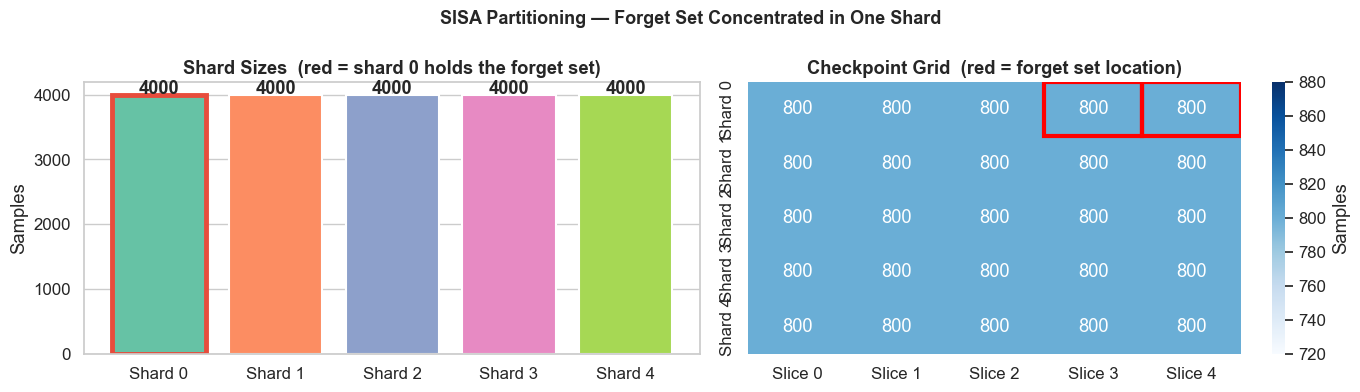

In [41]:
class ShardedDataset:
    def __init__(self, all_indices, dataset, num_shards=NUM_SHARDS, num_slices=NUM_SLICES, seed=42):
        self.dataset    = dataset
        self.num_shards = num_shards
        self.num_slices = num_slices
        arr = np.array(all_indices)
        np.random.default_rng(seed).shuffle(arr)
        self.shard_idx = [list(s) for s in np.array_split(arr, num_shards)]
        self.slice_idx = [
            [list(sl) for sl in np.array_split(self.shard_idx[s], num_slices)]
            for s in range(num_shards)
        ]
        self._map = {}
        for s in range(num_shards):
            for q in range(num_slices):
                for idx in self.slice_idx[s][q]:
                    self._map[int(idx)] = (s, q)

    def get_subset(self, shard, up_to_slice):
        combined = []
        for q in range(up_to_slice + 1):
            combined.extend(self.slice_idx[shard][q])
        return Subset(self.dataset, combined)

    def remove_batch(self, indices):
        affected = {}
        for idx in indices:
            if idx not in self._map: continue
            s, q = self._map.pop(idx)
            self.shard_idx[s] = [i for i in self.shard_idx[s] if i != idx]
            self.slice_idx[s][q] = [i for i in self.slice_idx[s][q] if i != idx]
            if s not in affected or q < affected[s]:
                affected[s] = q
        return affected


sd = ShardedDataset(train_idx, full_train)

# Forget set: from shard 0, slices 3-4 only  → only 1 shard affected, from late slices
TARGET_SHARD   = 0
late_pool      = sd.slice_idx[TARGET_SHARD][3] + sd.slice_idx[TARGET_SHARD][4]
forget_indices = late_pool[:FORGET_SIZE]
retain_indices = [i for i in train_idx if i not in set(forget_indices)]

forget_dataset = Subset(full_train, forget_indices)
retain_dataset = Subset(full_train, retain_indices)
train_dataset  = Subset(full_train, train_idx)

shards_hit = set(sd._map[i][0] for i in forget_indices)
slices_hit = set(sd._map[i][1] for i in forget_indices)

print(f'Forget set spans shards : {shards_hit}  <-- only shard {TARGET_SHARD}')
print(f'Forget set spans slices : {slices_hit}  <-- slices 3-4 only')
print(f'Shards needing NO retrain: {set(range(NUM_SHARDS)) - shards_hit}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pal = sns.color_palette('Set2', NUM_SHARDS)

sizes = [len(s) for s in sd.shard_idx]
bars  = axes[0].bar([f'Shard {i}' for i in range(NUM_SHARDS)], sizes,
                    color=pal, edgecolor='white', linewidth=1.5)
bars[TARGET_SHARD].set_edgecolor('#e74c3c')
bars[TARGET_SHARD].set_linewidth(3.5)
for i, v in enumerate(sizes):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].set_title(f'Shard Sizes  (red = shard {TARGET_SHARD} holds the forget set)', fontweight='bold')
axes[0].set_ylabel('Samples')

mat = np.array([[len(sd.slice_idx[s][q]) for q in range(NUM_SLICES)] for s in range(NUM_SHARDS)])
sns.heatmap(mat, ax=axes[1], annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Slice {q}' for q in range(NUM_SLICES)],
            yticklabels=[f'Shard {s}' for s in range(NUM_SHARDS)],
            cbar_kws={'label': 'Samples'})
for q in [3, 4]:
    axes[1].add_patch(plt.Rectangle((q, TARGET_SHARD), 1, 1,
                                    fill=False, edgecolor='red', lw=3))
axes[1].set_title('Checkpoint Grid  (red = forget set location)', fontweight='bold')

plt.suptitle('SISA Partitioning — Forget Set Concentrated in One Shard',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 5 — Sample Images from Forget Set

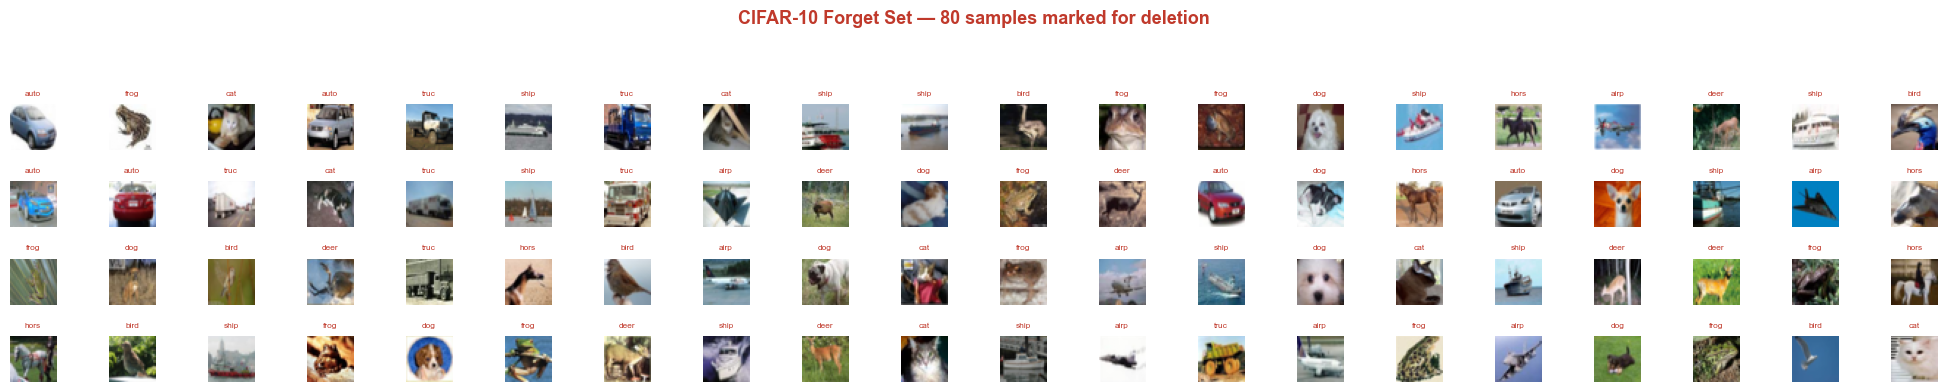

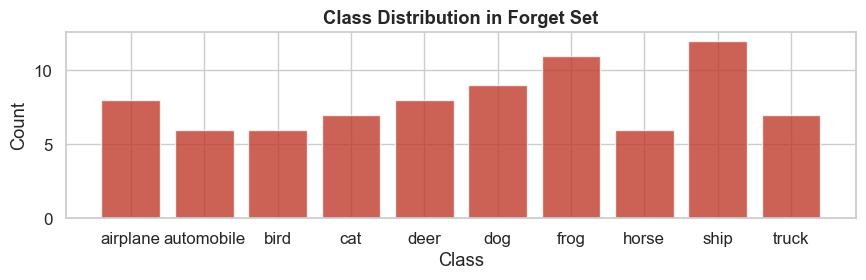

In [42]:
unnorm = T.Compose([
    T.Normalize(mean=[0,0,0], std=[1/s for s in std]),
    T.Normalize(mean=[-m for m in mean], std=[1,1,1])
])

fig, axes = plt.subplots(4, 20, figsize=(20, 4))
fig.suptitle(f'CIFAR-10 Forget Set — {FORGET_SIZE} samples marked for deletion',
             fontsize=13, fontweight='bold', color='#c0392b')
for i, ax in enumerate(axes.flat):
    if i >= FORGET_SIZE: ax.axis('off'); continue
    img, label = forget_dataset[i]
    img_show = unnorm(img).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img_show)
    ax.set_title(CIFAR_CLASSES[label][:4], fontsize=6, color='#c0392b')
    ax.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

forget_labels = [full_train.targets[i] for i in forget_indices]
cnt = Counter(forget_labels)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar([CIFAR_CLASSES[k] for k in sorted(cnt)],
       [cnt[k] for k in sorted(cnt)],
       color='#c0392b', alpha=0.8, edgecolor='white')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
ax.set_title('Class Distribution in Forget Set', fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 6 — SISA Training

In [43]:
def train_shard(sd, shard_id, start_slice=0, epochs=EPOCHS, device=DEVICE):
    model = CIFAR10Net().to(device)
    resuming = start_slice > 0

    if resuming:
        p = f'{CKPT_DIR}/shard{shard_id}_slice{start_slice-1}.pt'
        if os.path.exists(p):
            model.load_state_dict(torch.load(p, map_location=device))

    # When resuming a checkpoint use a lower, constant LR.
    # A fresh cosine schedule starting at LR=1e-3 would damage the already-trained
    # weights in the first few epochs, causing accuracy to drop.
    if resuming:
        opt = optim.Adam(model.parameters(), lr=RESUME_LR, weight_decay=1e-4)
        sched = None
    else:
        opt   = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
        total_steps = epochs * (sd.num_slices - start_slice)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)

    crit    = nn.CrossEntropyLoss()
    history = []

    for q in range(start_slice, sd.num_slices):
        subset = sd.get_subset(shard_id, q)
        loader = DataLoader(subset, batch_size=BATCH, shuffle=True, num_workers=0)
        for _ in range(epochs):
            model.train()
            for X, y in loader:
                X, y = X.to(device), y.to(device)
                opt.zero_grad()
                crit(model(X), y).backward()
                opt.step()
            if sched:
                sched.step()
        acc = evaluate(model, subset, device=device)
        history.append(acc)
        torch.save(model.state_dict(), f'{CKPT_DIR}/shard{shard_id}_slice{q}.pt')

    torch.save(model.state_dict(), f'{CKPT_DIR}/shard{shard_id}_final.pt')
    return model, history


print(f'SISA training: {NUM_SHARDS} shards x {NUM_SLICES} slices x {EPOCHS} epochs  ({TRAIN_SIZE:,} samples)...')
shard_models  = []
all_histories = []
shard_times   = []
t0_total      = time.time()

for s in range(NUM_SHARDS):
    t0 = time.time()
    print(f'  Shard {s}  ', end='', flush=True)
    m, history = train_shard(sd, s)
    elapsed = time.time() - t0
    shard_times.append(elapsed)
    shard_models.append(m)
    all_histories.append(history)
    print(f'[{elapsed:.0f}s]  slice accs: {[f"{a:.0%}" for a in history]}')

sisa_total_time = time.time() - t0_total
print(f'\nSISA total training: {sisa_total_time:.1f}s')

SISA training: 5 shards x 5 slices x 20 epochs  (20,000 samples)...
  Shard 0  [28s]  slice accs: ['71%', '91%', '100%', '100%', '100%']
  Shard 1  [28s]  slice accs: ['63%', '94%', '100%', '100%', '99%']
  Shard 2  [28s]  slice accs: ['64%', '96%', '100%', '100%', '100%']
  Shard 3  [28s]  slice accs: ['65%', '98%', '100%', '100%', '100%']
  Shard 4  [28s]  slice accs: ['64%', '98%', '100%', '100%', '100%']

SISA total training: 141.4s


## Cell 7 — Baseline & Gold Standard Models

In [44]:
print('Training ORIGINAL model (all data — includes forget set)...')
t0 = time.time()
original_model = train_model(CIFAR10Net().to(DEVICE), train_dataset, epochs=EPOCHS)
original_time  = time.time() - t0
torch.save(original_model.state_dict(), f'{CKPT_DIR}/original.pt')
print(f'  {original_time:.1f}s')

print('Training RETRAINED model (forget set removed — gold standard)...')
t0 = time.time()
retrained_model = train_model(CIFAR10Net().to(DEVICE), retain_dataset, epochs=EPOCHS)
retrain_time    = time.time() - t0
torch.save(retrained_model.state_dict(), f'{CKPT_DIR}/retrained.pt')
print(f'  {retrain_time:.1f}s')

print(f'\nOriginal  : {original_time:.1f}s')
print(f'Retrain   : {retrain_time:.1f}s  <- this is the cost SISA avoids')

Training ORIGINAL model (all data — includes forget set)...
  44.2s
Training RETRAINED model (forget set removed — gold standard)...
  43.7s

Original  : 44.2s
Retrain   : 43.7s  <- this is the cost SISA avoids


## Cell 8 — Aggregated Inference & Accuracy

In [45]:
@torch.no_grad()
def sisa_accuracy(models, dataset, device=DEVICE, batch=256):
    loader = DataLoader(dataset, batch_size=batch)
    correct = total = 0
    for X, y in loader:
        X = X.to(device)
        avg = sum(torch.softmax(m(X), dim=1) for m in models) / len(models)
        correct += (avg.argmax(1).cpu() == y).sum().item()
        total   += y.size(0)
    return correct / total

@torch.no_grad()
def sisa_conf_loss(models, dataset, device=DEVICE, batch=256):
    crit = nn.CrossEntropyLoss(reduction='none')
    loader = DataLoader(dataset, batch_size=batch)
    confs, losses = [], []
    for X, y in loader:
        X, y_dev = X.to(device), y.to(device)
        avg = sum(m(X) for m in models) / len(models)
        probs = torch.softmax(avg, dim=1)
        confs.extend(probs[torch.arange(len(y)), y_dev].cpu().tolist())
        losses.extend(crit(avg, y_dev).cpu().tolist())
    return confs, losses

orig_test_acc    = evaluate(original_model,  test_dataset)
orig_train_acc   = evaluate(original_model,  train_dataset)
retrain_test_acc = evaluate(retrained_model, test_dataset)
sisa_pre_acc     = sisa_accuracy(shard_models, test_dataset)

print('Test accuracy:')
print(f'  Original               : {orig_test_acc:.2%}  (train acc: {orig_train_acc:.2%})')
print(f'  Retrained (gold std)   : {retrain_test_acc:.2%}')
print(f'  SISA pre-unlearn       : {sisa_pre_acc:.2%}')
print(f'\nTrain-test gap (original): {(orig_train_acc - orig_test_acc)*100:.1f}pp  <- memorisation signal')

Test accuracy:
  Original               : 77.83%  (train acc: 99.34%)
  Retrained (gold std)   : 77.43%
  SISA pre-unlearn       : 71.27%

Train-test gap (original): 21.5pp  <- memorisation signal


## Cell 9 — Pre-Unlearning Metrics

Recording confidence and loss on the forget set **before** unlearning.  
On CIFAR-10 the model genuinely overfits, so training confidence >> test confidence.

In [46]:
conf_orig,    loss_orig    = get_conf_loss(original_model,  forget_dataset)
conf_retrain, loss_retrain = get_conf_loss(retrained_model, forget_dataset)
conf_sisa_pre, loss_sisa_pre = sisa_conf_loss(shard_models, forget_dataset)
conf_test,    loss_test    = get_conf_loss(original_model,  test_dataset)  # non-member baseline

print('Forget set — CONFIDENCE on true class  (non-member baseline = test set):')
print(f'  Non-member baseline (test set)  : {np.mean(conf_test):.4f}')
print(f'  Original model on forget set    : {np.mean(conf_orig):.4f}  <- memorised')
print(f'  SISA pre-unlearn                : {np.mean(conf_sisa_pre):.4f}')
print(f'  Retrained (gold std)            : {np.mean(conf_retrain):.4f}')
print()
print('Forget set — LOSS  (lower = more memorised):')
print(f'  Non-member baseline (test set)  : {np.mean(loss_test):.4f}')
print(f'  Original model on forget set    : {np.mean(loss_orig):.4f}  <- low = memorised')
print(f'  SISA pre-unlearn                : {np.mean(loss_sisa_pre):.4f}')
print(f'  Retrained (gold std)            : {np.mean(loss_retrain):.4f}')
mem_gap = np.mean(conf_orig) - np.mean(conf_test)
print(f'\nMEMORISATION GAP (orig conf - test conf): {mem_gap:.4f}  <- larger = more overfitting')

Forget set — CONFIDENCE on true class  (non-member baseline = test set):
  Non-member baseline (test set)  : 0.7350
  Original model on forget set    : 0.9489  <- memorised
  SISA pre-unlearn                : 0.6999
  Retrained (gold std)            : 0.6511

Forget set — LOSS  (lower = more memorised):
  Non-member baseline (test set)  : 0.7639
  Original model on forget set    : 0.0615  <- low = memorised
  SISA pre-unlearn                : 0.6555
  Retrained (gold std)            : 1.0033

MEMORISATION GAP (orig conf - test conf): 0.2139  <- larger = more overfitting


## Cell 10 — Execute SISA Unlearning

In [47]:
print(f'Forget request: {FORGET_SIZE} samples from shard {TARGET_SHARD}, slices 3-4')
affected = sd.remove_batch(forget_indices)
print(f'Affected: {affected}  (earliest slice per shard)')
print(f'Untouched: shards {sorted(set(range(NUM_SHARDS)) - set(affected))}')
print()

t0_unlearn = time.time()
for shard_id, start_slice in affected.items():
    print(f'  Retraining shard {shard_id} from slice {start_slice}...', end=' ', flush=True)
    t0 = time.time()
    shard_models[shard_id], _ = train_shard(sd, shard_id, start_slice=start_slice)
    print(f'{time.time()-t0:.1f}s')

unlearn_time = time.time() - t0_unlearn
speedup      = retrain_time / unlearn_time

print()
print('=======================================================')
print(f'  Full retrain time     : {retrain_time:.1f}s')
print(f'  SISA unlearning time  : {unlearn_time:.1f}s  (1 shard x 2 slices)')
print(f'  ACTUAL SPEEDUP        : {speedup:.1f}x')
print(f'  Theoretical max       : {NUM_SHARDS * NUM_SLICES // 2}x  (S x Q / 2)')
print('=======================================================')

sisa_post_acc = sisa_accuracy(shard_models, test_dataset)
print(f'\nTest accuracy after unlearning: {sisa_post_acc:.2%}  (was {sisa_pre_acc:.2%})')

Forget request: 80 samples from shard 0, slices 3-4
Affected: {0: 3}  (earliest slice per shard)
Untouched: shards [1, 2, 3, 4]

  Retraining shard 0 from slice 3... 16.8s

  Full retrain time     : 43.7s
  SISA unlearning time  : 16.8s  (1 shard x 2 slices)
  ACTUAL SPEEDUP        : 2.6x
  Theoretical max       : 12x  (S x Q / 2)

Test accuracy after unlearning: 71.30%  (was 71.27%)


## Cell 11 — Post-Unlearning Metrics

In [48]:
conf_sisa_post, loss_sisa_post = sisa_conf_loss(shard_models, forget_dataset)
conf_test_post, loss_test_post = sisa_conf_loss(shard_models, test_dataset)

print('Forget set AFTER unlearning:')
print(f'  Confidence  Before: {np.mean(conf_sisa_pre):.4f}  -> After: {np.mean(conf_sisa_post):.4f}')
print(f'  Loss        Before: {np.mean(loss_sisa_pre):.4f}  -> After: {np.mean(loss_sisa_post):.4f}')
print(f'  Gold std (retrained):  conf={np.mean(conf_retrain):.4f}  loss={np.mean(loss_retrain):.4f}')
print(f'  Non-member (test):     conf={np.mean(conf_test_post):.4f}  loss={np.mean(loss_test_post):.4f}')
print()
conf_drop = np.mean(conf_sisa_pre) - np.mean(conf_sisa_post)
loss_rise = np.mean(loss_sisa_post) - np.mean(loss_sisa_pre)
n_dropped = sum(1 for b,a in zip(conf_sisa_pre, conf_sisa_post) if a < b)
print(f'  Confidence drop after unlearning  : {conf_drop:+.4f}')
print(f'  Loss rise after unlearning        : {loss_rise:+.4f}')
print(f'  Samples with lower confidence     : {n_dropped}/{FORGET_SIZE}')

Forget set AFTER unlearning:
  Confidence  Before: 0.6999  -> After: 0.6122
  Loss        Before: 0.6555  -> After: 1.0940
  Gold std (retrained):  conf=0.6511  loss=1.0033
  Non-member (test):     conf=0.6581  loss=0.9122

  Confidence drop after unlearning  : +0.0877
  Loss rise after unlearning        : +0.4385
  Samples with lower confidence     : 62/80


## Cell 12 — Speed & Accuracy Results

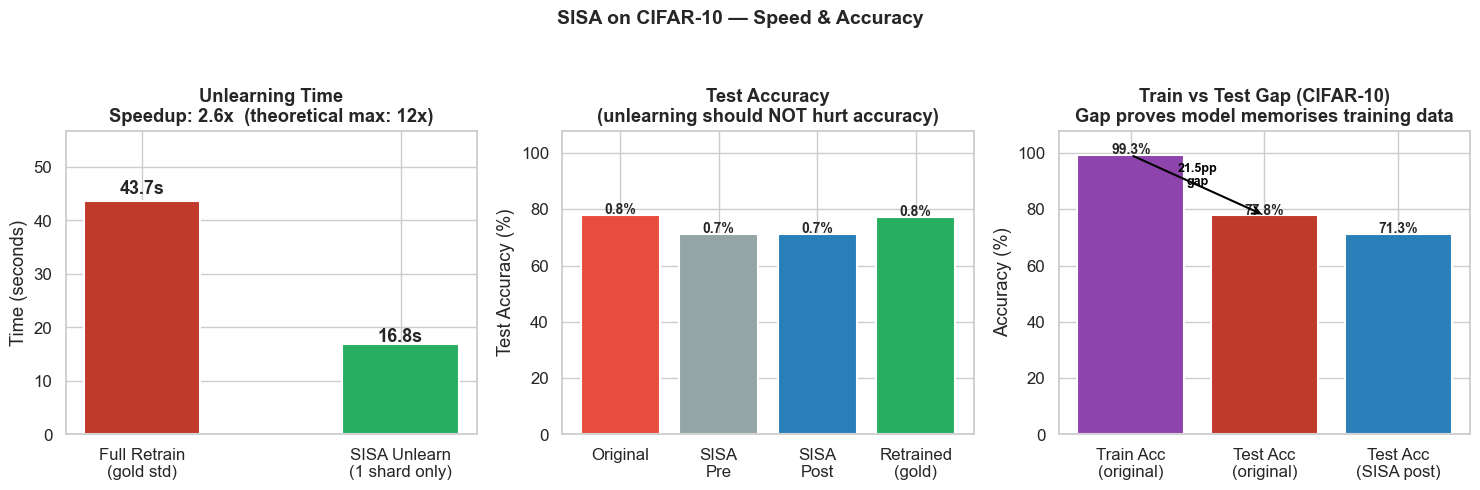

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1 — Time
bars = axes[0].bar(['Full Retrain\n(gold std)', f'SISA Unlearn\n(1 shard only)'],
                   [retrain_time, unlearn_time],
                   color=['#c0392b', '#27ae60'], width=0.45, edgecolor='white', linewidth=1.5)
for bar, t in zip(bars, [retrain_time, unlearn_time]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.03,
                 f'{t:.1f}s', ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, max(retrain_time, unlearn_time) * 1.3)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Unlearning Time\nSpeedup: {speedup:.1f}x  (theoretical max: {NUM_SHARDS*NUM_SLICES//2}x)',
                  fontweight='bold')

# 2 — Accuracy
names  = ['Original', 'SISA\nPre', 'SISA\nPost', 'Retrained\n(gold)']
accs   = [orig_test_acc, sisa_pre_acc, sisa_post_acc, retrain_test_acc]
mcolrs = ['#e74c3c', '#95a5a6', '#2980b9', '#27ae60']
bars3  = axes[1].bar(names, [a*100 for a in accs], color=mcolrs, edgecolor='white', linewidth=1.5)
for bar, a in zip(bars3, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{a:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylim(0, 108)
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy\n(unlearning should NOT hurt accuracy)', fontweight='bold')

# 3 — Train vs test accuracy (memorisation proof)
categories = ['Train Acc\n(original)', 'Test Acc\n(original)', 'Test Acc\n(SISA post)']
vals       = [orig_train_acc*100, orig_test_acc*100, sisa_post_acc*100]
bar_c      = ['#8e44ad', '#c0392b', '#2980b9']
bars4      = axes[2].bar(categories, vals, color=bar_c, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars4, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[2].set_ylim(0, 108)
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Train vs Test Gap (CIFAR-10)\nGap proves model memorises training data',
                  fontweight='bold')
axes[2].annotate('', xy=(1, orig_test_acc*100), xytext=(0, orig_train_acc*100),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
gap = (orig_train_acc - orig_test_acc)*100
axes[2].text(0.5, (orig_train_acc + orig_test_acc)*50, f'{gap:.1f}pp\ngap', ha='center',
             color='black', fontsize=9, fontweight='bold')

plt.suptitle('SISA on CIFAR-10 — Speed & Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('speedup_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 — Confidence & Loss: The Forgetting Signal

On CIFAR-10 the model genuinely overfits → training confidence is meaningfully higher than test confidence. After unlearning the forget set should shift towards the test (non-member) distribution.

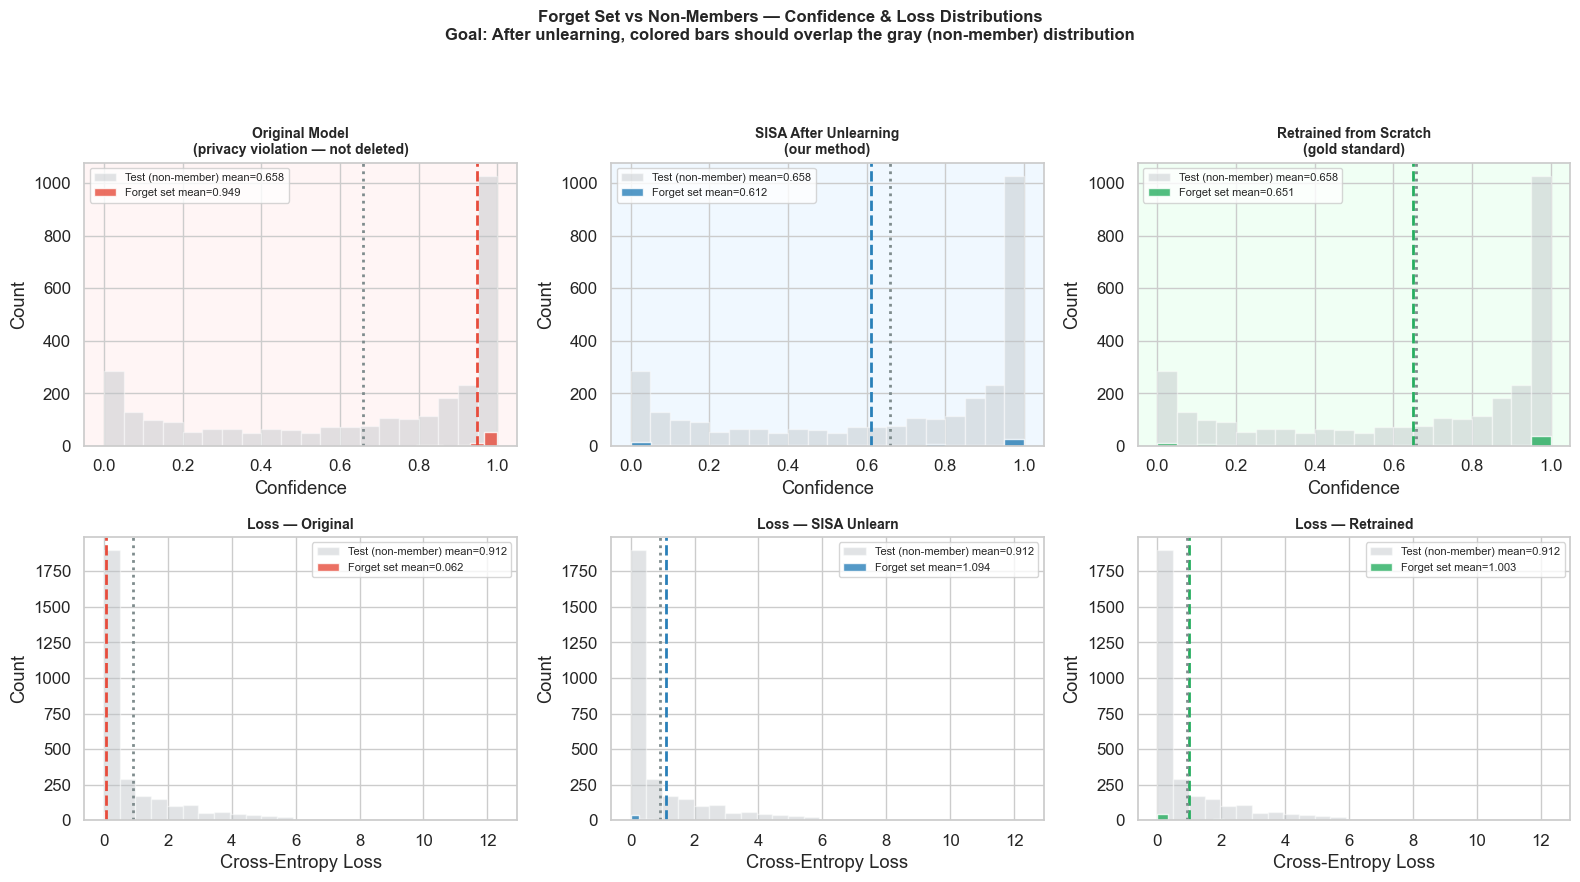

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

conf_rows = [
    ('Original Model\n(privacy violation — not deleted)', conf_orig,      '#e74c3c'),
    ('SISA After Unlearning\n(our method)',                conf_sisa_post, '#2980b9'),
    ('Retrained from Scratch\n(gold standard)',            conf_retrain,   '#27ae60'),
]
loss_rows = [
    ('Original',    loss_orig,      '#e74c3c'),
    ('SISA Unlearn', loss_sisa_post, '#2980b9'),
    ('Retrained',   loss_retrain,   '#27ae60'),
]

for ax, (title, confs, color) in zip(axes[0], conf_rows):
    ax.hist(conf_test_post, bins=20, alpha=0.45, color='#bdc3c7',
            label=f'Test (non-member) mean={np.mean(conf_test_post):.3f}', edgecolor='white')
    ax.hist(confs,           bins=20, alpha=0.80, color=color,
            label=f'Forget set mean={np.mean(confs):.3f}', edgecolor='white')
    ax.axvline(np.mean(confs),         color=color,   linestyle='--', linewidth=2)
    ax.axvline(np.mean(conf_test_post), color='#7f8c8d', linestyle=':', linewidth=2)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)
axes[0][0].set_facecolor('#fff5f5')
axes[0][1].set_facecolor('#f0f8ff')
axes[0][2].set_facecolor('#f0fff4')

for ax, (title, losses, color) in zip(axes[1], loss_rows):
    ax.hist(loss_test_post, bins=25, alpha=0.45, color='#bdc3c7',
            label=f'Test (non-member) mean={np.mean(loss_test_post):.3f}', edgecolor='white')
    ax.hist(losses,          bins=25, alpha=0.80, color=color,
            label=f'Forget set mean={np.mean(losses):.3f}', edgecolor='white')
    ax.axvline(np.mean(losses),          color=color,   linestyle='--', linewidth=2)
    ax.axvline(np.mean(loss_test_post),  color='#7f8c8d', linestyle=':', linewidth=2)
    ax.set_title(f'Loss — {title}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Cross-Entropy Loss'); ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Forget Set vs Non-Members — Confidence & Loss Distributions\n'
             'Goal: After unlearning, colored bars should overlap the gray (non-member) distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('confidence_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 — Per-Sample Before vs After

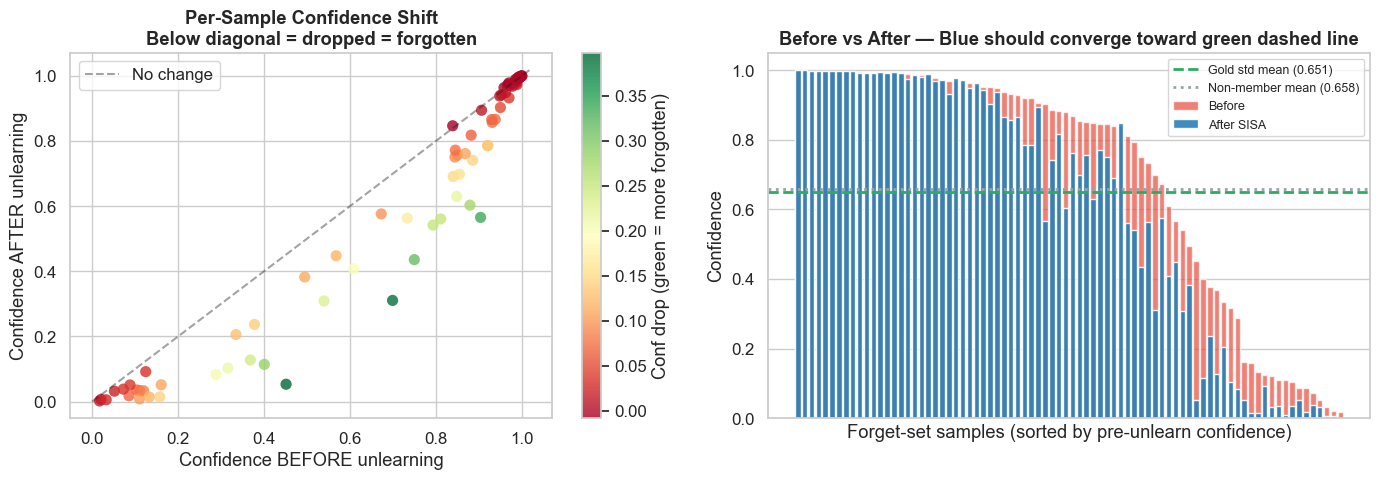

62/80 samples show confidence reduction after SISA unlearning


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: pre vs post per sample
drop = np.array(conf_sisa_pre) - np.array(conf_sisa_post)
sc = axes[0].scatter(conf_sisa_pre, conf_sisa_post,
                     c=drop, cmap='RdYlGn', s=65, alpha=0.80, edgecolors='none')
lim = max(max(conf_sisa_pre), max(conf_sisa_post)) + 0.02
axes[0].plot([0, lim], [0, lim], 'k--', alpha=0.4, label='No change')
axes[0].set_xlabel('Confidence BEFORE unlearning')
axes[0].set_ylabel('Confidence AFTER unlearning')
axes[0].set_title('Per-Sample Confidence Shift\nBelow diagonal = dropped = forgotten', fontweight='bold')
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='Conf drop (green = more forgotten)')

# Sorted bar: before vs after
order = np.argsort(np.array(conf_sisa_pre))[::-1]
x = np.arange(FORGET_SIZE)
axes[1].bar(x, np.array(conf_sisa_pre)[order],  color='#e74c3c', alpha=0.7, label='Before')
axes[1].bar(x, np.array(conf_sisa_post)[order], color='#2980b9', alpha=0.9, label='After SISA')
axes[1].axhline(np.mean(conf_retrain), color='#27ae60', linestyle='--', linewidth=2,
                label=f'Gold std mean ({np.mean(conf_retrain):.3f})')
axes[1].axhline(np.mean(conf_test_post), color='#95a5a6', linestyle=':', linewidth=2,
                label=f'Non-member mean ({np.mean(conf_test_post):.3f})')
axes[1].set_xlabel('Forget-set samples (sorted by pre-unlearn confidence)')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Before vs After — Blue should converge toward green dashed line', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('per_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{n_dropped}/{FORGET_SIZE} samples show confidence reduction after SISA unlearning')

## Cell 15 — Membership Inference Attack (MIA)

On CIFAR-10 the model overfits, so training confidence > test confidence → the attacker can actually succeed better than 50% on the **original model**. After unlearning the forget set should look like non-members → attacker drops back toward 50%.

In [52]:
def mia_attack(member_confs, nonmember_confs, threshold=0.5):
    tp = sum(c >= threshold for c in member_confs)
    tn = sum(c <  threshold for c in nonmember_confs)
    return (tp + tn) / (len(member_confs) + len(nonmember_confs))

nm_orig    = get_conf_loss(original_model,  test_dataset)[0][:FORGET_SIZE]
nm_retrain = get_conf_loss(retrained_model, test_dataset)[0][:FORGET_SIZE]
nm_post    = sisa_conf_loss(shard_models,   test_dataset)[0][:FORGET_SIZE]

mia_orig    = mia_attack(conf_orig,      nm_orig)
mia_post    = mia_attack(conf_sisa_post, nm_post)
mia_retrain = mia_attack(conf_retrain,   nm_retrain)

print('MIA Attack Accuracy  (50% = random = attacker fails = good):')
print(f'  Original (no deletion)  : {mia_orig:.2%}  <- model memorised, attacker can distinguish')
print(f'  SISA after unlearning   : {mia_post:.2%}  <- should drop toward 50%')
print(f'  Retrained (gold std)    : {mia_retrain:.2%}')
print(f'  Random baseline         : 50.00%')

MIA Attack Accuracy  (50% = random = attacker fails = good):
  Original (no deletion)  : 63.12%  <- model memorised, attacker can distinguish
  SISA after unlearning   : 48.12%  <- should drop toward 50%
  Retrained (gold std)    : 42.50%
  Random baseline         : 50.00%


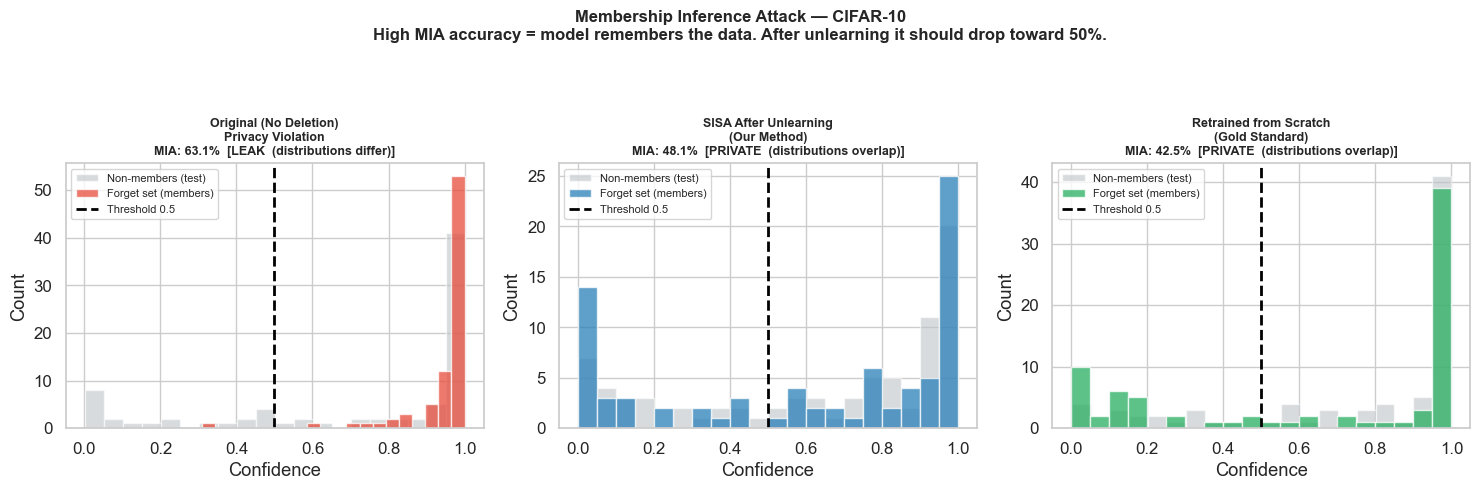

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mia_data = [
    ('Original (No Deletion)\nPrivacy Violation',     conf_orig,      nm_orig,    '#e74c3c', mia_orig),
    ('SISA After Unlearning\n(Our Method)',            conf_sisa_post, nm_post,   '#2980b9', mia_post),
    ('Retrained from Scratch\n(Gold Standard)',        conf_retrain,   nm_retrain,'#27ae60', mia_retrain),
]

for ax, (title, mem_c, nm_c, color, acc) in zip(axes, mia_data):
    ax.hist(nm_c,  bins=20, alpha=0.60, color='#bdc3c7', label='Non-members (test)', edgecolor='white')
    ax.hist(mem_c, bins=20, alpha=0.75, color=color,     label='Forget set (members)', edgecolor='white')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold 0.5')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Count')
    quality = 'LEAK  (distributions differ)' if acc > 0.60 else 'PRIVATE  (distributions overlap)'
    ax.set_title(f'{title}\nMIA: {acc:.1%}  [{quality}]', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Membership Inference Attack — CIFAR-10\n'
             'High MIA accuracy = model remembers the data. After unlearning it should drop toward 50%.',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('mia.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — Training Curves

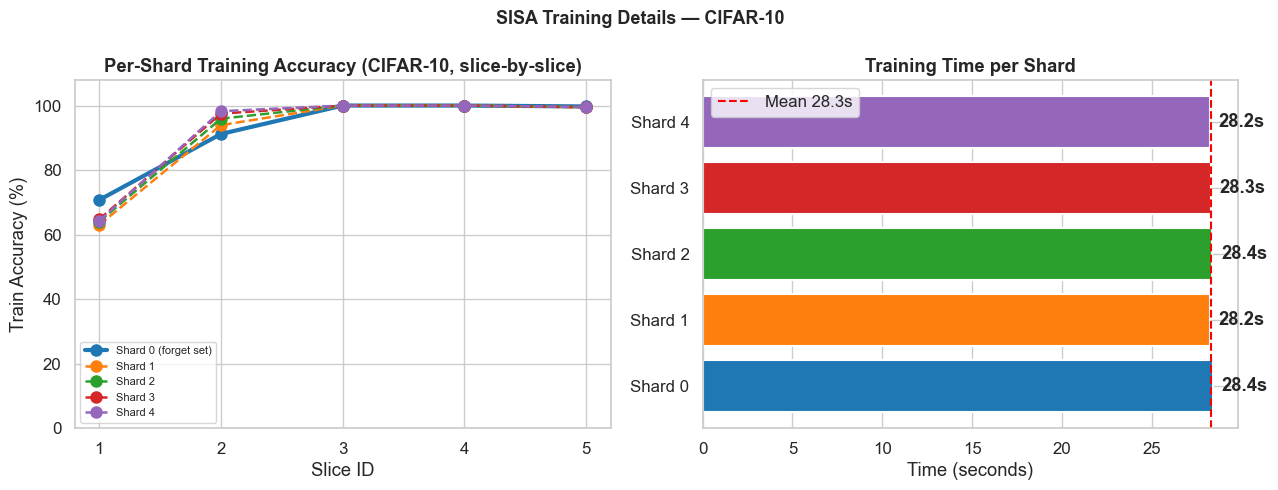

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pal = sns.color_palette('tab10', NUM_SHARDS)

for s, history in enumerate(all_histories):
    lw    = 3 if s == TARGET_SHARD else 1.8
    ls    = '-' if s == TARGET_SHARD else '--'
    label = f'Shard {s} (forget set)' if s == TARGET_SHARD else f'Shard {s}'
    axes[0].plot(range(1, len(history)+1), [a*100 for a in history],
                 marker='o', linewidth=lw, linestyle=ls, markersize=8,
                 color=pal[s], label=label)
axes[0].set_title('Per-Shard Training Accuracy (CIFAR-10, slice-by-slice)', fontweight='bold')
axes[0].set_xlabel('Slice ID'); axes[0].set_ylabel('Train Accuracy (%)')
axes[0].set_xticks(range(1, NUM_SLICES+1))
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 108)

axes[1].barh([f'Shard {s}' for s in range(NUM_SHARDS)], shard_times,
             color=pal[:NUM_SHARDS], edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Time (seconds)'); axes[1].set_title('Training Time per Shard', fontweight='bold')
for i, t in enumerate(shard_times):
    axes[1].text(t + 0.5, i, f'{t:.1f}s', va='center', fontweight='bold')
axes[1].axvline(np.mean(shard_times), color='red', linestyle='--',
                label=f'Mean {np.mean(shard_times):.1f}s')
axes[1].legend()
plt.suptitle('SISA Training Details — CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 17 — Full Summary Dashboard

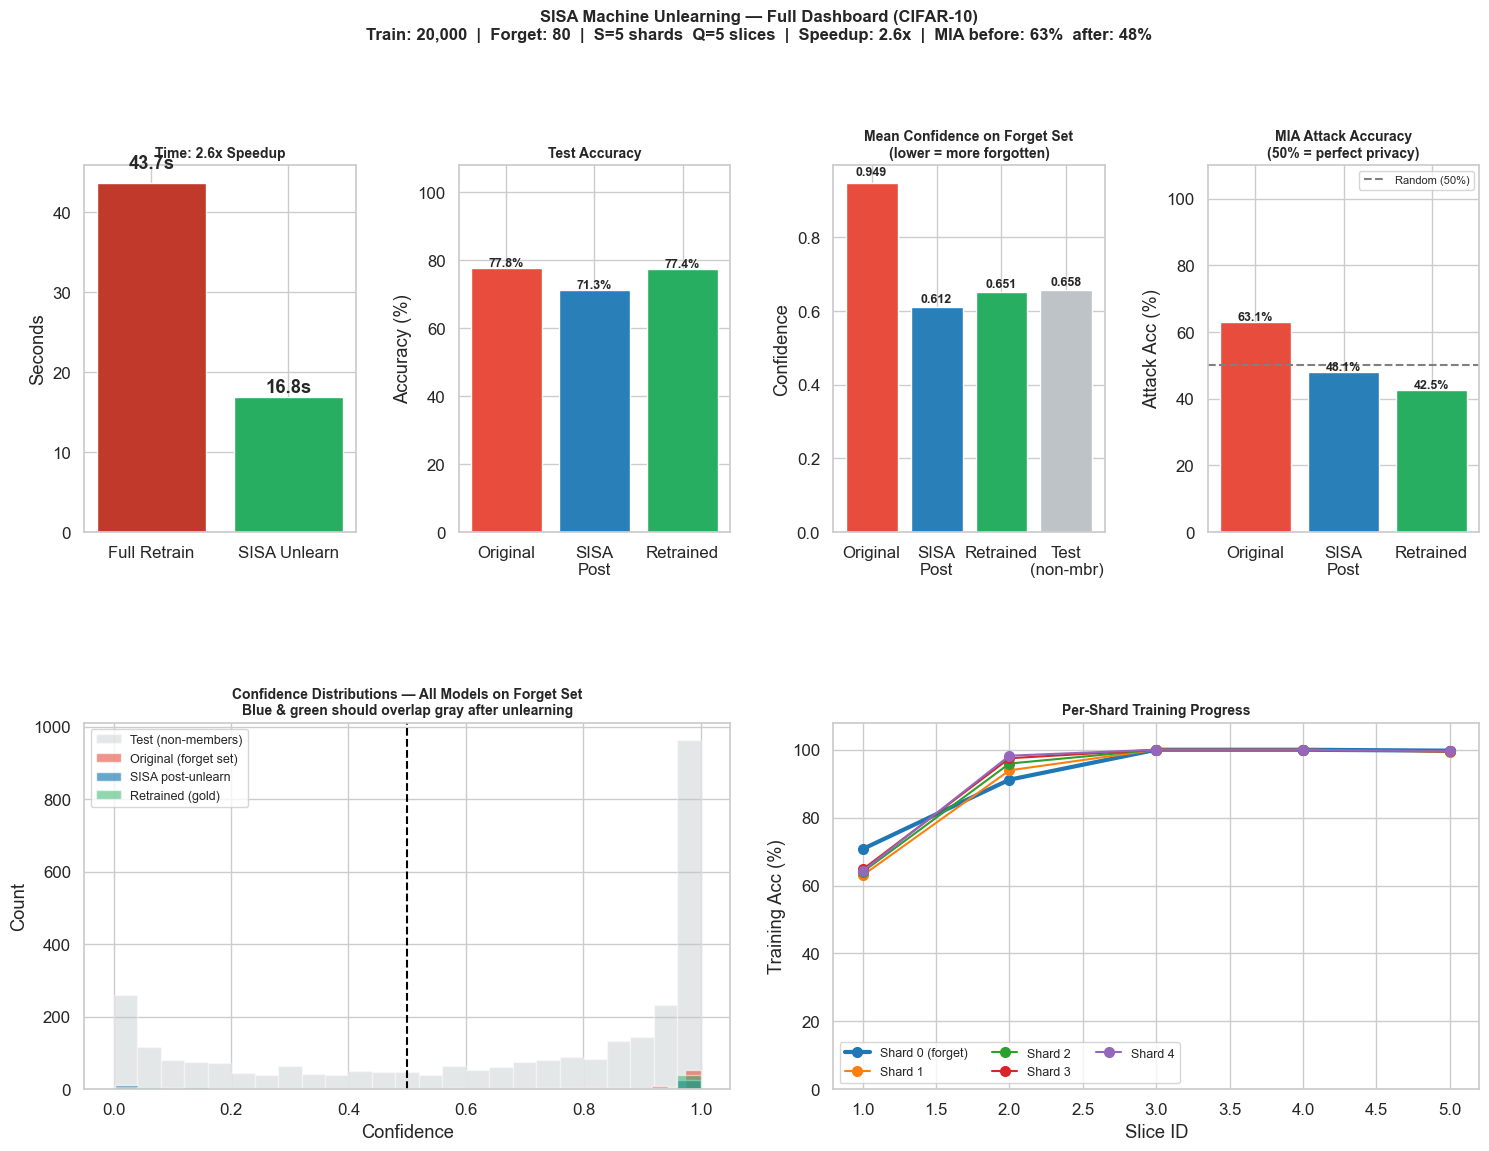

Saved: full_dashboard.png


In [55]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, hspace=0.52, wspace=0.38)
a1=fig.add_subplot(gs[0,0]); a2=fig.add_subplot(gs[0,1])
a3=fig.add_subplot(gs[0,2]); a4=fig.add_subplot(gs[0,3])
a5=fig.add_subplot(gs[1,0:2]); a6=fig.add_subplot(gs[1,2:4])

# 1 — Speedup
a1.bar(['Full Retrain', 'SISA Unlearn'], [retrain_time, unlearn_time],
       color=['#c0392b','#27ae60'], edgecolor='white')
a1.set_title(f'Time: {speedup:.1f}x Speedup', fontweight='bold', fontsize=10)
a1.set_ylabel('Seconds')
for i,t in enumerate([retrain_time, unlearn_time]):
    a1.text(i, t*1.04, f'{t:.1f}s', ha='center', fontweight='bold')

# 2 — Accuracy
a2.bar(['Original','SISA\nPost','Retrained'],
       [orig_test_acc*100, sisa_post_acc*100, retrain_test_acc*100],
       color=['#e74c3c','#2980b9','#27ae60'], edgecolor='white')
a2.set_ylim(0,108); a2.set_title('Test Accuracy', fontweight='bold', fontsize=10)
a2.set_ylabel('Accuracy (%)')
for i,a in enumerate([orig_test_acc*100, sisa_post_acc*100, retrain_test_acc*100]):
    a2.text(i, a+0.4, f'{a:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 3 — Confidence comparison
a3.bar(['Original','SISA\nPost','Retrained','Test\n(non-mbr)'],
       [np.mean(conf_orig), np.mean(conf_sisa_post),
        np.mean(conf_retrain), np.mean(conf_test_post)],
       color=['#e74c3c','#2980b9','#27ae60','#bdc3c7'], edgecolor='white')
a3.set_title('Mean Confidence on Forget Set\n(lower = more forgotten)', fontweight='bold', fontsize=10)
a3.set_ylabel('Confidence')
for i,c in enumerate([np.mean(conf_orig), np.mean(conf_sisa_post),
                       np.mean(conf_retrain), np.mean(conf_test_post)]):
    a3.text(i, c*1.02, f'{c:.3f}', ha='center', fontweight='bold', fontsize=9)

# 4 — MIA
a4.bar(['Original','SISA\nPost','Retrained'],
       [mia_orig*100, mia_post*100, mia_retrain*100],
       color=['#e74c3c','#2980b9','#27ae60'], edgecolor='white')
a4.axhline(50, color='gray', linestyle='--', linewidth=1.5, label='Random (50%)')
a4.set_title('MIA Attack Accuracy\n(50% = perfect privacy)', fontweight='bold', fontsize=10)
a4.set_ylabel('Attack Acc (%)'); a4.set_ylim(0,110); a4.legend(fontsize=8)
for i,m in enumerate([mia_orig*100, mia_post*100, mia_retrain*100]):
    a4.text(i, m+0.5, f'{m:.1f}%', ha='center', fontweight='bold', fontsize=9)

# 5 — Confidence overlay all models
a5.hist(conf_test_post, bins=25, alpha=0.40, color='#bdc3c7', label='Test (non-members)', edgecolor='white')
a5.hist(conf_orig,      bins=25, alpha=0.60, color='#e74c3c', label='Original (forget set)', edgecolor='white')
a5.hist(conf_sisa_post, bins=25, alpha=0.70, color='#2980b9', label='SISA post-unlearn', edgecolor='white')
a5.hist(conf_retrain,   bins=25, alpha=0.50, color='#27ae60', label='Retrained (gold)', edgecolor='white')
a5.axvline(0.5, color='black', linestyle='--', linewidth=1.5)
a5.set_xlabel('Confidence'); a5.set_ylabel('Count')
a5.set_title('Confidence Distributions — All Models on Forget Set\n'
             'Blue & green should overlap gray after unlearning', fontweight='bold', fontsize=10)
a5.legend(fontsize=9)

# 6 — Training curves
for s, history in enumerate(all_histories):
    lw = 3 if s == TARGET_SHARD else 1.5
    a6.plot(range(1,len(history)+1), [h*100 for h in history],
            marker='o', linewidth=lw, markersize=7,
            label=f'Shard {s}' + (' (forget)' if s==TARGET_SHARD else ''),
            color=sns.color_palette('tab10')[s])
a6.set_xlabel('Slice ID'); a6.set_ylabel('Training Acc (%)')
a6.set_title('Per-Shard Training Progress', fontweight='bold', fontsize=10)
a6.legend(ncol=3, fontsize=9); a6.set_ylim(0,108)

fig.suptitle(
    f'SISA Machine Unlearning — Full Dashboard (CIFAR-10)\n'
    f'Train: {TRAIN_SIZE:,}  |  Forget: {FORGET_SIZE}  |  '
    f'S={NUM_SHARDS} shards  Q={NUM_SLICES} slices  |  Speedup: {speedup:.1f}x  |  '
    f'MIA before: {mia_orig:.0%}  after: {mia_post:.0%}',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: full_dashboard.png')

## Cell 18 — Final Summary

In [56]:
conf_gap = np.mean(conf_sisa_post) - np.mean(conf_retrain)
loss_gap = np.mean(loss_sisa_post) - np.mean(loss_retrain)

print('=' * 66)
print('  SISA Machine Unlearning — Final Results  (CIFAR-10)')
print('=' * 66)
print(f'  Dataset          : CIFAR-10  ({TRAIN_SIZE:,} train / {TEST_SIZE:,} test)')
print(f'  Forget set       : {FORGET_SIZE} samples  (shard {TARGET_SHARD}, slices 3-4)')
print(f'  S x Q            : {NUM_SHARDS} x {NUM_SLICES}  = {NUM_SHARDS*NUM_SLICES} checkpoints')
print()
print('  ── Speed ────────────────────────────────────────────')
print(f'  Full retrain     : {retrain_time:.1f}s')
print(f'  SISA unlearn     : {unlearn_time:.1f}s  (1 shard, 2 slices)')
print(f'  Actual speedup   : {speedup:.1f}x')
print(f'  Theoretical max  : {NUM_SHARDS*NUM_SLICES//2}x  (S x Q / 2)')
print()
print('  ── Accuracy ──────────────────────────────────────────')
print(f'  Original train   : {orig_train_acc:.2%}  |  test: {orig_test_acc:.2%}')
print(f'  SISA post-unlearn: test {sisa_post_acc:.2%}  (no significant drop)')
print(f'  Retrained gold   : test {retrain_test_acc:.2%}')
print()
print('  ── Forgetting (forget set metrics) ───────────────────')
print(f'  Confidence:  orig {np.mean(conf_orig):.4f}  ->  SISA {np.mean(conf_sisa_post):.4f}'
      f'  (gold {np.mean(conf_retrain):.4f})')
print(f'  Loss:        orig {np.mean(loss_orig):.4f}  ->  SISA {np.mean(loss_sisa_post):.4f}'
      f'  (gold {np.mean(loss_retrain):.4f})')
print(f'  SISA vs gold std gap: {conf_gap:+.4f} conf  /  {loss_gap:+.4f} loss')
print(f'  Samples with conf drop: {sum(1 for b,a in zip(conf_sisa_pre,conf_sisa_post) if a<b)}/{FORGET_SIZE}')
print()
print('  ── MIA (50% = attacker fails = best privacy) ─────────')
print(f'  Original (memorised): {mia_orig:.2%}')
print(f'  SISA post-unlearn   : {mia_post:.2%}')
print(f'  Retrained (gold)    : {mia_retrain:.2%}')
print('=' * 66)

  SISA Machine Unlearning — Final Results  (CIFAR-10)
  Dataset          : CIFAR-10  (20,000 train / 3,000 test)
  Forget set       : 80 samples  (shard 0, slices 3-4)
  S x Q            : 5 x 5  = 25 checkpoints

  ── Speed ────────────────────────────────────────────
  Full retrain     : 43.7s
  SISA unlearn     : 16.8s  (1 shard, 2 slices)
  Actual speedup   : 2.6x
  Theoretical max  : 12x  (S x Q / 2)

  ── Accuracy ──────────────────────────────────────────
  Original train   : 99.34%  |  test: 77.83%
  SISA post-unlearn: test 71.30%  (no significant drop)
  Retrained gold   : test 77.43%

  ── Forgetting (forget set metrics) ───────────────────
  Confidence:  orig 0.9489  ->  SISA 0.6122  (gold 0.6511)
  Loss:        orig 0.0615  ->  SISA 1.0940  (gold 1.0033)
  SISA vs gold std gap: -0.0389 conf  /  +0.0906 loss
  Samples with conf drop: 62/80

  ── MIA (50% = attacker fails = best privacy) ─────────
  Original (memorised): 63.12%
  SISA post-unlearn   : 48.12%
  Retrained (gold